In [53]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

# Try project imports first.
# If your package is installed / notebook is run from project root, these should work directly.
from agentic_energy.schemas import BatteryParams, DayInputs, SolveRequest, SolveResponse
from agentic_energy.milp.milp_mcp_server import records_to_arrays, solve_daily_milp
from agentic_energy.milp.robust_baselines import (
    estimate_bias, apply_bias, residual_matrix, sample_scenarios, 
    solve_bias_corrected_deterministic,
    solve_scenario_expected_cost,
    solve_scenario_cvar 
)  
from agentic_energy.data_loader import EnergyDataLoader, BatteryDataLoader
from agentic_energy.schemas import BatteryParams, DayInputs, EnergyDataRecord, SolveFromRecordsRequest

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True


In [54]:
REGION="ITALY"
data_version = "forecast"
forecast_type = "RF"
duration_hours=4
capacity=43.13
soc_init=0.5
soc_min=0.0
soc_max=1.0
eta_c = 0.80
eta_d = 0.80
soc_target=0.5

CVAR_SEEDS = [0, 1, 2, 3, 4,5,6,7,8,9]

# common CVaR confidence levels meaning
#  we optimize for the worst 10%, 5%, or 1% of scenarios
# BETAS = [0.90, 0.95, 0.99] 
BETAS = [0.95]
# risk aversion levels from risk-neutral (0.0) to fully robust (1.0) meaning 
# we weight the CVaR term from 0% to 100% in the objective
# LAMBDAS = [0.0, 0.25, 0.5, 0.75, 1.0]
LAMBDAS = [0.5]
N_SCENARIOS = 100
BLOCK_BOOTSTRAP = True 


history_start_date="2018-01-01"
history_end_date="2018-12-31"
test_start_date="2019-12-01"
test_end_date="2019-12-01"

In [55]:
history_forecast_obj = EnergyDataLoader(region = REGION, data_version=data_version, forecast_type=forecast_type)
history_forecast_data = history_forecast_obj.load_region_data()
history_forecast = await history_forecast_obj.get_filtered_data(history_start_date, history_end_date)

test_forecast_obj = EnergyDataLoader(region = REGION, data_version=data_version, forecast_type=forecast_type)
test_forecast_data = test_forecast_obj.load_region_data()
test_forecast = await test_forecast_obj.get_filtered_data(test_start_date, test_end_date)

2026-04-14 22:50:53.250 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/Italy_data_forecast_RF.csv
2026-04-14 22:50:53.380 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/Italy_data_forecast_RF.csv


In [56]:
history_actual_obj = EnergyDataLoader(region=REGION, data_version = "actual")
history_actual_data = history_actual_obj.load_region_data()
history_actual = await history_actual_obj.get_filtered_data(start_date=history_start_date, end_date=history_end_date)

test_actual_obj = EnergyDataLoader(region=REGION, data_version = "actual")
test_actual_data = test_actual_obj.load_region_data()
test_actual = await test_actual_obj.get_filtered_data(start_date=test_start_date, end_date=test_end_date)

2026-04-14 22:50:53.475 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/Italy_data_actual.csv
2026-04-14 22:50:53.565 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/Italy_data_actual.csv


In [57]:
from datetime import datetime, timedelta
stats= await EnergyDataLoader.get_summary_stats_from_ag(history_actual_data)
timedelta = datetime.strptime(stats.states[0].date_range.end, "%Y-%m-%d %H:%M:%S") - datetime.strptime(stats.states[0].date_range.start, "%Y-%m-%d %H:%M:%S")
days = timedelta.days + 1
days

365

In [58]:
def keep_full_days(records):
    """
    Filters the input records to keep only those that belong to full days 
    (i.e., days with 24 hourly records). Returns the filtered records and the list of valid dates.
    """
    rows = [r for r in records if r.prices is not None and r.consumption is not None]
    rows = sorted(rows, key=lambda r: r.timestamps)

    grouped = {}
    for r in rows:
        d = pd.to_datetime(r.timestamps).date()
        grouped.setdefault(d, []).append(r)

    full_day_records = []
    valid_dates = []

    for d in sorted(grouped.keys()):
        day_rows = sorted(grouped[d], key=lambda r: r.timestamps)
        if len(day_rows) == 24:
            full_day_records.extend(day_rows)
            valid_dates.append(d)

    return full_day_records, valid_dates


history_forecast_records, history_dates = keep_full_days(history_forecast.states)
history_actual_records, _ = keep_full_days(history_actual.states)

test_forecast_records, test_dates = keep_full_days(test_forecast.states)
test_actual_records, _ = keep_full_days(test_actual.states)

print(len(history_dates), len(test_dates))
print(len(history_forecast_records), len(history_actual_records))
print(len(test_forecast_records), len(test_actual_records))

364 1
8736 8736
24 24


In [59]:
# capacity = 43.13  # MWh
batterydetails = BatteryParams(
    capacity_MWh=capacity,   # 4-hour energy at 100 MW power: good for diurnal spreads
    soc_init=soc_init,        # neutral start
    soc_min=soc_min,         # keep 10% buffer for longevity + contingency
    soc_max=soc_max,         # avoid top-of-charge stress
    cmax_MW=capacity/duration_hours,        # 4-hour duration (capacity/4)
    dmax_MW=capacity/duration_hours,        # symmetric charge/discharge
    eta_c=eta_c,           # ~92% round-trip when paired with eta_d
    eta_d=eta_d,
    soc_target=soc_target       # keep headroom to buy when prices dip; adjust by time-of-day policy
)
# batterydetails = batt.compute_battery_params()
print(batterydetails)

capacity_MWh=43.13 soc_init=0.5 soc_min=0.0 soc_max=1.0 cmax_MW=10.7825 dmax_MW=10.7825 eta_c=0.8 eta_d=0.8 soc_target=0.5


In [60]:
price_actual_hist = []
price_forecast_hist = []
demand_actual_hist = []
demand_forecast_hist = []

for i in range(len(history_forecast_records) // 24):
    forecast_prices, forecast_demand = records_to_arrays(
        history_forecast_records[i*24:(i+1)*24]
    )
    actual_prices, actual_demand = records_to_arrays(
        history_actual_records[i*24:(i+1)*24]
    )

    price_forecast_hist.append(forecast_prices)
    demand_forecast_hist.append(forecast_demand)
    price_actual_hist.append(actual_prices)
    demand_actual_hist.append(actual_demand)

price_actual_hist = np.array(price_actual_hist, dtype=float)
price_forecast_hist = np.array(price_forecast_hist, dtype=float)
demand_actual_hist = np.array(demand_actual_hist, dtype=float)
demand_forecast_hist = np.array(demand_forecast_hist, dtype=float)

print(price_actual_hist.shape)
print(price_forecast_hist.shape)
print(demand_actual_hist.shape)
print(demand_forecast_hist.shape)

(364, 24)
(364, 24)
(364, 24)
(364, 24)


In [61]:
price_bias = estimate_bias(price_actual_hist, price_forecast_hist)
demand_bias = estimate_bias(demand_actual_hist, demand_forecast_hist)

price_residuals = residual_matrix(price_actual_hist, price_forecast_hist, bias_correct=True)
demand_residuals = residual_matrix(demand_actual_hist, demand_forecast_hist, bias_correct=True)

print(price_bias.shape, demand_bias.shape)
print(price_residuals.shape, demand_residuals.shape)

(24,) (24,)
(364, 24) (364, 24)


In [62]:
all_results_cvar = {}
all_day_info_cvar = {}

for beta in BETAS:
    for lam in LAMBDAS:
        for seed in CVAR_SEEDS:
            print(f"\nRunning CVaR MILP | beta={beta} | lambda={lam} | seed={seed}")

            results_cvar = []
            day_info_cvar = []

            n_days = len(test_forecast_records) // 24

            for i in range(n_days):
                print(f"  Solving day {i+1} of {n_days}")

                forecast_prices, forecast_demand = records_to_arrays(
                    test_forecast_records[i*24:(i+1)*24]
                )
                actual_prices, actual_demand = records_to_arrays(
                    test_actual_records[i*24:(i+1)*24]
                )

                forecast_prices = np.asarray(forecast_prices, dtype=float)
                forecast_demand = np.asarray(forecast_demand, dtype=float)
                actual_prices = np.asarray(actual_prices, dtype=float)
                actual_demand = np.asarray(actual_demand, dtype=float)

                # bias-corrected forecast
                price_forecast_corr = apply_bias(forecast_prices, price_bias)
                demand_forecast_corr = apply_bias(forecast_demand, demand_bias)

                # scenarios vary with seed
                price_scenarios = sample_scenarios(
                    base_forecast=price_forecast_corr,
                    residuals=price_residuals,
                    n_scenarios=N_SCENARIOS,
                    random_state=seed + i,
                    block_bootstrap=BLOCK_BOOTSTRAP,
                )

                demand_scenarios = sample_scenarios(
                    base_forecast=demand_forecast_corr,
                    residuals=demand_residuals,
                    n_scenarios=N_SCENARIOS,
                    random_state=seed + 1000 + i,
                    block_bootstrap=BLOCK_BOOTSTRAP,
                )

                res_cvar = solve_scenario_cvar(
                    batt=batterydetails,
                    price_scenarios=price_scenarios,
                    demand_scenarios=demand_scenarios,
                    beta=beta,
                    lam=lam,
                    dt_hours=1.0,
                    prices_sell_scenarios=price_scenarios,
                    solver="GUROBI",
                    solver_opts=None,
                )

                day_cvar = DayInputs(
                    prices_buy=actual_prices.tolist(),
                    demand_MW=actual_demand.tolist(),
                    prices_sell=actual_prices.tolist(),
                    allow_export=True,
                    dt_hours=1.0,
                    prices_buy_forecast=price_forecast_corr.tolist(),
                    demand_MW_forecast=demand_forecast_corr.tolist(),
                    prices_sell_forecast=price_forecast_corr.tolist(),
                )

                results_cvar.append(res_cvar)
                day_info_cvar.append(day_cvar)

            all_results_cvar[(beta, lam, seed)] = results_cvar
            all_day_info_cvar[(beta, lam, seed)] = day_info_cvar


Running CVaR MILP | beta=0.95 | lambda=0.5 | seed=0
  Solving day 1 of 1

Running CVaR MILP | beta=0.95 | lambda=0.5 | seed=1
  Solving day 1 of 1

Running CVaR MILP | beta=0.95 | lambda=0.5 | seed=2
  Solving day 1 of 1

Running CVaR MILP | beta=0.95 | lambda=0.5 | seed=3
  Solving day 1 of 1

Running CVaR MILP | beta=0.95 | lambda=0.5 | seed=4
  Solving day 1 of 1

Running CVaR MILP | beta=0.95 | lambda=0.5 | seed=5
  Solving day 1 of 1

Running CVaR MILP | beta=0.95 | lambda=0.5 | seed=6
  Solving day 1 of 1

Running CVaR MILP | beta=0.95 | lambda=0.5 | seed=7
  Solving day 1 of 1

Running CVaR MILP | beta=0.95 | lambda=0.5 | seed=8
  Solving day 1 of 1

Running CVaR MILP | beta=0.95 | lambda=0.5 | seed=9
  Solving day 1 of 1


In [63]:
def build_eval_df_for_cvar_seed(
    day_info,
    result,
    batterydetails,
    beta,
    lam,
    seed,
    price_bias=None,
    demand_bias=None,
    method_name="scenario_cvar",
    dt_hours=1.0,
):
    eval_data = {
        "method": [],
        "beta": [],
        "lambda": [],
        "seed": [],
        "day_index": [],
        "hour": [],
        "prices_actual": [],
        "prices_forecast": [],
        "prices_bias_corrected": [],
        "actual_demand": [],
        "forecast_demand": [],
        "demand_bias_corrected": [],
        "soc": [],
        "charge_MW": [],
        "discharge_MW": [],
        "import_MW": [],
        "export_MW": [],
    }

    for day_idx, (eval_req, output) in enumerate(zip(day_info, result)):
        prices_actual = np.array(eval_req.prices_buy, dtype=float)
        prices_forecast = np.array(eval_req.prices_buy_forecast, dtype=float)

        actual_demand = np.array(eval_req.demand_MW, dtype=float)
        forecast_demand = np.array(eval_req.demand_MW_forecast, dtype=float)

        if price_bias is not None:
            prices_bias_corrected = apply_bias(prices_forecast, price_bias)
        else:
            prices_bias_corrected = prices_forecast.copy()

        if demand_bias is not None:
            demand_bias_corrected = apply_bias(forecast_demand, demand_bias)
        else:
            demand_bias_corrected = forecast_demand.copy()

        export_vals = output.export_MW if output.export_MW is not None else [0.0] * len(output.charge_MW)
        import_vals = output.import_MW if output.import_MW is not None else [np.nan] * len(output.charge_MW)

        for h in range(len(prices_actual)):
            eval_data["method"].append(method_name)
            eval_data["beta"].append(beta)
            eval_data["lambda"].append(lam)
            eval_data["seed"].append(seed)
            eval_data["day_index"].append(day_idx)
            eval_data["hour"].append(h)

            eval_data["prices_actual"].append(prices_actual[h])
            eval_data["prices_forecast"].append(prices_forecast[h])
            eval_data["prices_bias_corrected"].append(prices_bias_corrected[h])

            eval_data["actual_demand"].append(actual_demand[h])
            eval_data["forecast_demand"].append(forecast_demand[h])
            eval_data["demand_bias_corrected"].append(demand_bias_corrected[h])

            eval_data["soc"].append(output.soc[h])
            eval_data["charge_MW"].append(output.charge_MW[h])
            eval_data["discharge_MW"].append(output.discharge_MW[h])
            eval_data["import_MW"].append(import_vals[h])
            eval_data["export_MW"].append(export_vals[h])

    eval_df = pd.DataFrame(eval_data)

    eval_df["profit_step"] = (
        (eval_df["discharge_MW"] - eval_df["charge_MW"])
        * eval_df["prices_actual"]
        * dt_hours
    )

    eval_df["profit_step_system"] = (
        eval_df["export_MW"] * eval_df["prices_actual"]
        - eval_df["import_MW"] * eval_df["prices_actual"]
    ) * dt_hours

    return eval_df

In [64]:
cvar_eval_dfs = []

for beta in BETAS:
    for lam in LAMBDAS:
        for seed in CVAR_SEEDS:
            eval_df_cfg = build_eval_df_for_cvar_seed(
                day_info=all_day_info_cvar[(beta, lam, seed)],
                result=all_results_cvar[(beta, lam, seed)],
                batterydetails=batterydetails,
                beta=beta,
                lam=lam,
                seed=seed,
                price_bias=price_bias,
                demand_bias=demand_bias,
                method_name="scenario_cvar",
                dt_hours=1.0,
            )
            cvar_eval_dfs.append(eval_df_cfg)

eval_df_cvar_all = pd.concat(cvar_eval_dfs, ignore_index=True)
eval_df_cvar_all.head()

,method,beta,lambda,seed,day_index,hour,prices_actual,prices_forecast,prices_bias_corrected,actual_demand,forecast_demand,demand_bias_corrected,soc,charge_MW,discharge_MW,import_MW,export_MW,profit_step,profit_step_system
0,scenario_cvar,0.95,0.5,0,0,0,65.10,55.693682,55.711684,28.68,27.214783,27.217930,0.500,0.000000,0.0,NaN,0.0,0.000000,NaN
1,scenario_cvar,0.95,0.5,0,0,1,62.12,53.145097,53.217804,27.12,25.619543,25.619617,0.500,0.000000,0.0,NaN,0.0,0.000000,NaN
2,scenario_cvar,0.95,0.5,0,0,2,59.05,51.045797,51.089775,25.99,24.607153,24.630326,0.500,0.000000,0.0,NaN,0.0,0.000000,NaN
3,scenario_cvar,0.95,0.5,0,0,3,59.00,47.419306,47.472374,25.62,24.226387,24.231682,0.500,6.739063,0.0,NaN,0.0,-397.604688,NaN
4,scenario_cvar,0.95,0.5,0,0,4,56.63,47.407525,47.407789,25.66,24.187409,24.197100,0.625,0.000000,0.0,NaN,0.0,0.000000,NaN


In [65]:
eval_df_cvar_all.shape

(240, 19)

In [66]:
24*len(CVAR_SEEDS)*len(BETAS)*len(LAMBDAS)

240

In [67]:
# day level profit per configuration (method, beta, lambda, seed)
cvar_day_profit_df = (
    eval_df_cvar_all
    .groupby(["method", "beta", "lambda", "seed", "day_index"], as_index=False)
    .agg(
        total_profit=("profit_step", "sum"),
        total_profit_system=("profit_step_system", "sum"),
    )
)

cvar_day_profit_df.head()

,method,beta,lambda,seed,day_index,total_profit,total_profit_system
0,scenario_cvar,0.95,0.5,0,0,1278.750588,0.0
1,scenario_cvar,0.95,0.5,1,0,1281.823600,0.0
2,scenario_cvar,0.95,0.5,2,0,1221.872900,0.0
3,scenario_cvar,0.95,0.5,3,0,1278.750588,0.0
4,scenario_cvar,0.95,0.5,4,0,1294.722166,0.0


In [68]:
cvar_day_profit_df.shape

(10, 7)

In [69]:
LAMBDAS, BETAS, CVAR_SEEDS

([0.5], [0.95], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [70]:
# help me create different dataframes for each beta/lambda combination to analyze distributions of daily profits, e.g. via boxplots or histograms. For example, start with beta=0.90 and lambda=0.0:
for beta in BETAS:
    for lam in LAMBDAS:
        df_subset = cvar_day_profit_df[(cvar_day_profit_df["beta"] == beta) & (cvar_day_profit_df["lambda"] == lam)]
        print(f"Beta: {beta}, Lambda: {lam}, Shape: {df_subset.shape}")
        print(f"Mean Total Profit: {df_subset['total_profit'].mean()}")
        print(f"Std Dev Total Profit: {df_subset['total_profit'].std()} \n")

Beta: 0.95, Lambda: 0.5, Shape: (10, 7)
Mean Total Profit: 1275.6681403125
Std Dev Total Profit: 29.173861605702434 



In [71]:
# per seed summary for each (method, beta, lambda) configuration
cvar_seed_summary = (
    cvar_day_profit_df
    .groupby(["method", "beta", "lambda", "seed"], as_index=False)
    .agg(
        mean_daily_profit=("total_profit", "mean"),
        std_daily_profit=("total_profit", "std"),
        median_daily_profit=("total_profit", "median"),
        p5_daily_profit=("total_profit", lambda x: np.quantile(x, 0.05)),
        cum_profit=("total_profit", "sum"),
    )
)

cvar_seed_summary.head()

,method,beta,lambda,seed,mean_daily_profit,std_daily_profit,median_daily_profit,p5_daily_profit,cum_profit
0,scenario_cvar,0.95,0.5,0,1278.750588,NaN,1278.750588,1278.750588,1278.750588
1,scenario_cvar,0.95,0.5,1,1281.823600,NaN,1281.823600,1281.823600,1281.823600
2,scenario_cvar,0.95,0.5,2,1221.872900,NaN,1221.872900,1221.872900,1221.872900
3,scenario_cvar,0.95,0.5,3,1278.750588,NaN,1278.750588,1278.750588,1278.750588
4,scenario_cvar,0.95,0.5,4,1294.722166,NaN,1294.722166,1294.722166,1294.722166


In [72]:
cvar_final_summary = (
    cvar_seed_summary
    .groupby(["method", "beta", "lambda"], as_index=False)
    .agg(
        seed_mean_daily_profit=("mean_daily_profit", "mean"),
        seed_std_daily_profit=("mean_daily_profit", "std"),
        seed_mean_cum_profit=("cum_profit", "mean"),
        seed_std_cum_profit=("cum_profit", "std"),
        seed_mean_p5_profit=("p5_daily_profit", "mean"),
        seed_std_p5_profit=("p5_daily_profit", "std"),
        seed_mean_day_std=("std_daily_profit", "mean"),
    )
)

cvar_final_summary.head()

,method,beta,lambda,seed_mean_daily_profit,seed_std_daily_profit,seed_mean_cum_profit,seed_std_cum_profit,seed_mean_p5_profit,seed_std_p5_profit,seed_mean_day_std
0,scenario_cvar,0.95,0.5,1275.66814,29.173862,1275.66814,29.173862,1275.66814,29.173862,NaN


In [73]:
cvar_seed_summary.shape ,cvar_final_summary.shape

((10, 9), (1, 10))

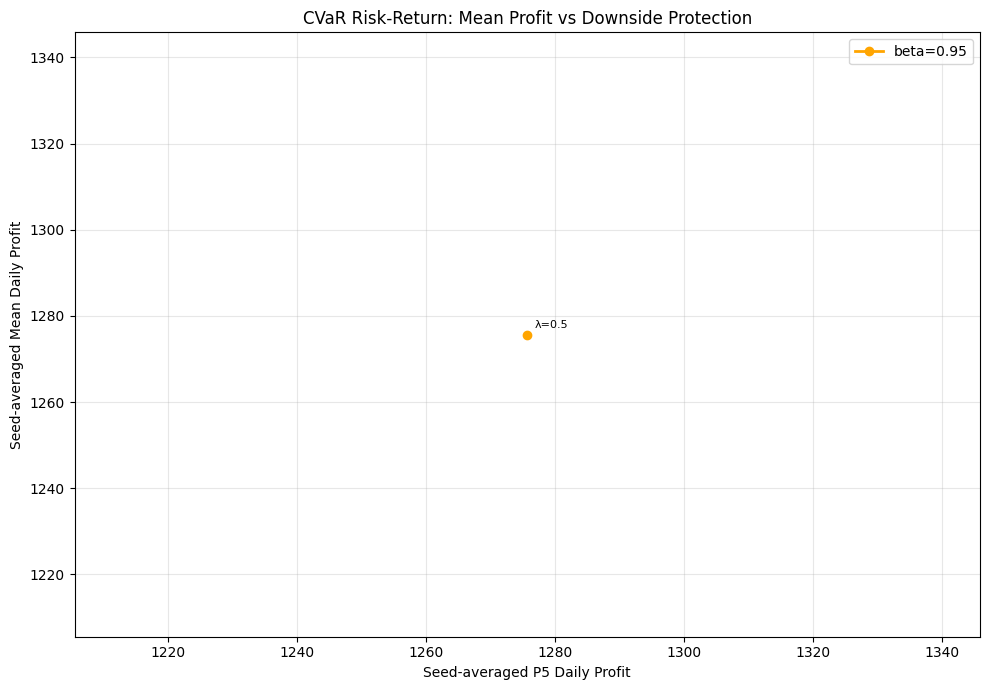

In [74]:
def plot_risk_return_curve_downside(
    summary_df,
    x_col="seed_mean_p5_profit",
    y_col="seed_mean_daily_profit",
    title="CVaR Risk-Return Curve",
):
    plt.figure(figsize=(10, 7))

    betas = sorted(summary_df["beta"].unique())
    colors = {0.90: "blue", 0.95: "orange", 0.99: "green"}

    for beta in betas:
        g = summary_df[summary_df["beta"] == beta].sort_values("lambda")
        plt.plot(
            g[x_col],
            g[y_col],
            marker="o",
            linewidth=2,
            label=f"beta={beta}",
            color=colors.get(beta, None),
        )

        for _, row in g.iterrows():
            plt.annotate(
                f"λ={row['lambda']}",
                (row[x_col], row[y_col]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8,
            )

    plt.xlabel("Seed-averaged P5 Daily Profit")
    plt.ylabel("Seed-averaged Mean Daily Profit")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_risk_return_curve_downside(
    cvar_final_summary,
    x_col="seed_mean_p5_profit",
    y_col="seed_mean_daily_profit",
    title="CVaR Risk-Return: Mean Profit vs Downside Protection",
)    

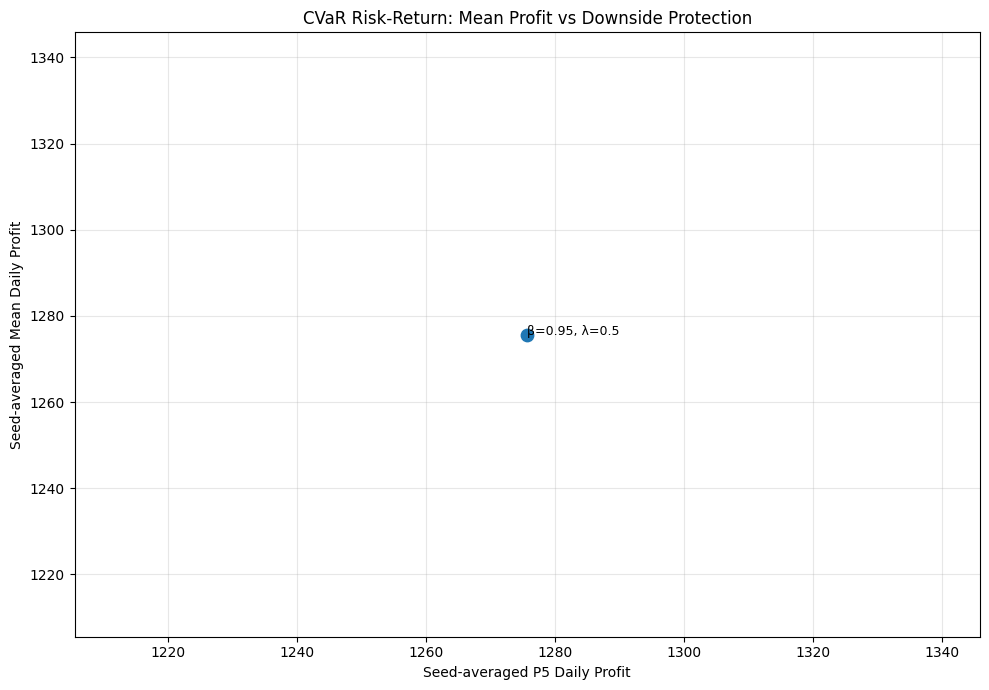

In [75]:
def plot_risk_return_curve_downside(
    summary_df,
    downside_col="seed_mean_p5_profit",
    y_col="seed_mean_daily_profit",
    title="CVaR Risk-Return Curve (Downside)",
):
    plt.figure(figsize=(10, 7))

    for _, row in summary_df.iterrows():
        x = row[downside_col]
        y = row[y_col]
        label = f"β={row['beta']}, λ={row['lambda']}"
        plt.scatter(x, y, s=80)
        plt.text(x, y, label, fontsize=9)

    plt.xlabel("Seed-averaged P5 Daily Profit")
    plt.ylabel("Seed-averaged Mean Daily Profit")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_risk_return_curve_downside(
    cvar_final_summary,
    downside_col="seed_mean_p5_profit",
    y_col="seed_mean_daily_profit",
    title="CVaR Risk-Return: Mean Profit vs Downside Protection",
)

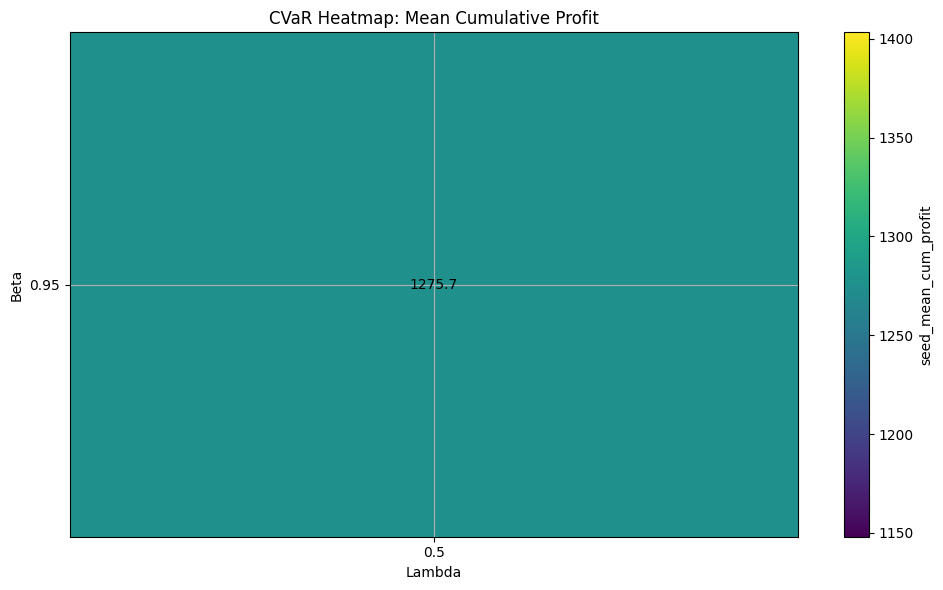

In [76]:
def plot_cvar_heatmap(summary_df, value_col="seed_mean_cum_profit", title="CVaR Heatmap"):
    pivot_df = summary_df.pivot(index="beta", columns="lambda", values=value_col)

    plt.figure(figsize=(10, 6))
    im = plt.imshow(pivot_df.values, aspect="auto")

    plt.xticks(np.arange(len(pivot_df.columns)), pivot_df.columns)
    plt.yticks(np.arange(len(pivot_df.index)), pivot_df.index)

    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            val = pivot_df.iloc[i, j]
            plt.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=10)

    plt.colorbar(im, label=value_col)
    plt.xlabel("Lambda")
    plt.ylabel("Beta")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_cvar_heatmap(
    cvar_final_summary,
    value_col="seed_mean_cum_profit",
    title="CVaR Heatmap: Mean Cumulative Profit",
)




In [77]:
def plot_cvar_errorbar(summary_df, title="CVaR Mean Cumulative Profit Across Seeds"):
    plt.figure(figsize=(12, 7))

    labels = []
    means = []
    stds = []

    for _, row in summary_df.iterrows():
        labels.append(f"β={row['beta']}, λ={row['lambda']}")
        means.append(row["seed_mean_cum_profit"])
        stds.append(row["seed_std_cum_profit"])

    x = np.arange(len(labels))

    plt.errorbar(x, means, yerr=stds, fmt='o', capsize=5)
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel("Mean Cumulative Profit")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

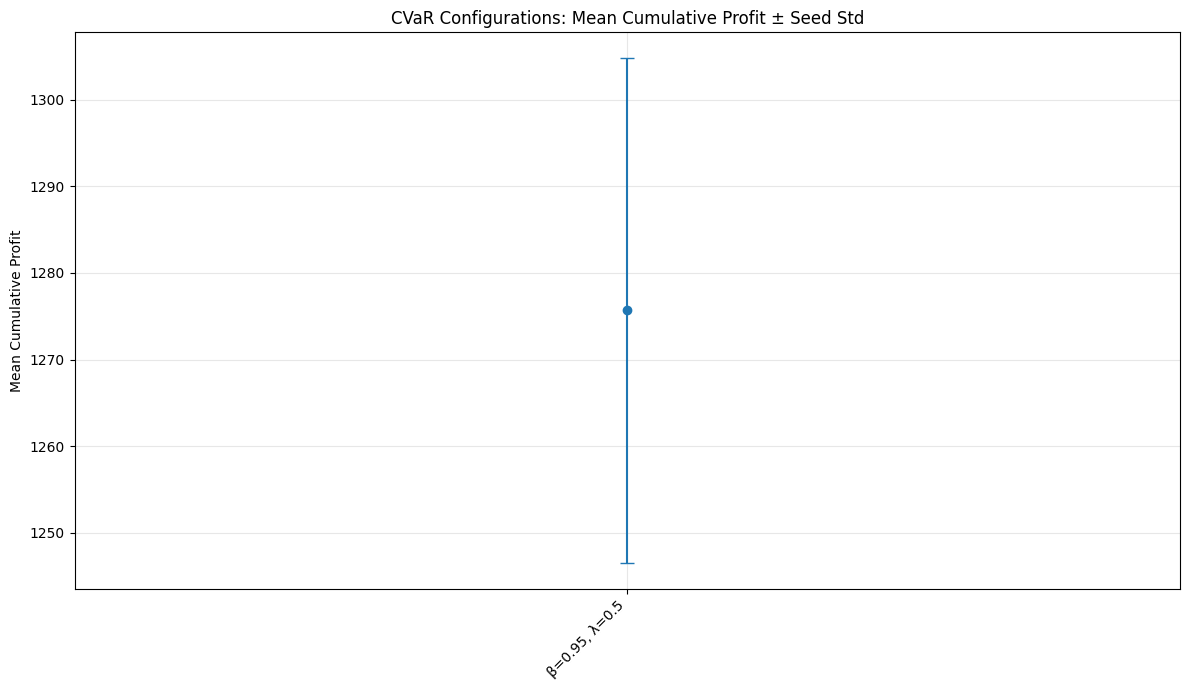

In [78]:
plot_cvar_errorbar(
    cvar_final_summary,
    title="CVaR Configurations: Mean Cumulative Profit ± Seed Std",
)